# Warp block basics

Regress a series $y$ on a covariate $x$ after a **generative** time warp:

$$\hat{y}_i = A \cdot \mathrm{warp}(x, p)_i + C$$

(Here $f$ is just the linear map $A\,\cdot\,+\,C$.) The path $p$ is low-dimensional (knot coefficients). Without the warp, $x$ and $y$ look unrelated; with the right $p$, they line up.

This example is **deterministic** (no observation noise), so we fit with **error only** — residual likelihood on $y$, warping still allowed — equivalent to setting the dual-loss weight to favour the error term alone ($\lambda \to 1$). See [`1_Introduction_to_Warp_Regression.ipynb`](1_Introduction_to_Warp_Regression.ipynb) for the full dual loss and terror likelihood.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from warp_regression import WarpPath, WarpRegression, soft_warp_numpy
from warp_regression.core.training import gaussian_error_nll

plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.3})


## 1. Synthetic data

Build $y$ from a **simple expanding linear warp** of a sine covariate: $p(i) = r\,i$ with rate $r = 0.85 < 1$. No observation noise — just input $\to$ warp $\to$ affine output.


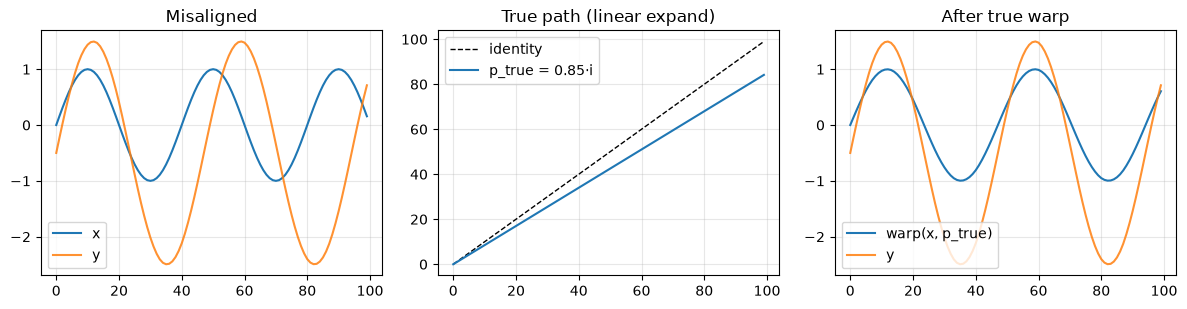

n=100, n_knots=8, rate=0.85, A=2, C=-0.5, terminal offset=-14.9


In [2]:
n, n_knots = 100, 8
idx = np.arange(n, dtype=np.float64)

# Expanding linear warp: constant rate < 1 (noticeable stretch, no clipping).
rate = 0.85
p_true = rate * idx
A_true, C_true = 2.0, -0.5

x = np.sin(2.0 * np.pi * 2.5 * idx / n)
y = A_true * soft_warp_numpy(x, p_true) + C_true
x_t, y_t = torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(idx, x, label="x"); axes[0].plot(idx, y, label="y", alpha=0.85)
axes[0].set_title("Misaligned"); axes[0].legend()
axes[1].plot(idx, idx, "k--", lw=1, label="identity")
axes[1].plot(idx, p_true, label=f"p_true = {rate:g}·i")
axes[1].set_title("True path (linear expand)"); axes[1].legend()
axes[2].plot(idx, soft_warp_numpy(x, p_true), label="warp(x, p_true)")
axes[2].plot(idx, y, label="y", alpha=0.85)
axes[2].set_title("After true warp"); axes[2].legend()
plt.tight_layout(); plt.show()
print(
    f"n={n}, n_knots={n_knots}, rate={rate:g}, A={A_true:g}, C={C_true:g}, "
    f"terminal offset={p_true[-1] - idx[-1]:.1f}"
)


## 2. A warp layer

`WarpPath` holds the knot coefficients $B$ (and a timing scale $\sigma_t$ used when terror is active).
`WarpRegression` soft-warps a covariate at those indices.
Wrap both with a linear readout so training is ordinary PyTorch:


In [3]:
class AffineWarpLayer(nn.Module):
    def __init__(self, n: int, n_knots: int) -> None:
        super().__init__()
        self.path = WarpPath(n, n_knots, path_anchor="start")
        self.warp = WarpRegression(self.path, covariate_kind="array", name="x")
        self.A = nn.Parameter(torch.tensor(1.0))
        self.C = nn.Parameter(torch.tensor(0.0))
        # Fixed residual scale — data are noiseless; learning σ_y here lets the path go jagged.
        self.register_buffer("log_sigma", torch.tensor(float(np.log(0.05))))

    def forward(self, x: torch.Tensor):
        p = self.path.path()
        return self.A * self.warp.warp(x, p) + self.C, p


layer0 = AffineWarpLayer(n, n_knots)
with torch.no_grad():
    y0, p0 = layer0(x_t)
nll0 = float(gaussian_error_nll(y_t - y0, torch.exp(layer0.log_sigma)).detach())
print(f"init (B=0): max |p−i|={float((p0 - torch.arange(n)).abs().max()):.1e}  error NLL={nll0:.1f}")


init (B=0): max |p−i|=0.0e+00  error NLL=41811.3


## 3. Error-only fit

Train $B$, $A$, $C$ on residual NLL alone (warping still free). Residual scale is held fixed — with noiseless $y$, learning $\sigma_y$ lets the path wander. For dual loss and terror, see the introduction notebook.


In [4]:
def fit_error_only(epochs=5000, lr=0.05):
    layer = AffineWarpLayer(n, n_knots)
    opt = torch.optim.Adam([layer.path.B, layer.A, layer.C], lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        y_hat, _ = layer(x_t)
        gaussian_error_nll(y_t - y_hat, torch.exp(layer.log_sigma)).backward()
        opt.step()
    with torch.no_grad():
        y_hat, p = layer(x_t)
    return {
        "layer": layer,
        "p": p.numpy(),
        "y_hat": y_hat.numpy(),
        "A": float(layer.A.detach()),
        "C": float(layer.C.detach()),
    }


fit = fit_error_only()
with torch.no_grad():
    nll = float(
        gaussian_error_nll(
            y_t - torch.tensor(fit["y_hat"]),
            torch.exp(fit["layer"].log_sigma),
        ).detach()
    )
print(
    f"error-only: error NLL={nll:.1f}  "
    f"mean |p−p_true|={np.mean(np.abs(fit['p'] - p_true)):.3f}  "
    f"A={fit['A']:.3f} (true {A_true:g})  C={fit['C']:.3f} (true {C_true:g})"
)


error-only: error NLL=-207.7  mean |p−p_true|=0.000  A=2.000 (true 2)  C=-0.500 (true -0.5)


## 4. Recovered path

The error-only fit recovers the linear expand and the affine readout. For terror, $\sigma_t$, and path-sampled forecasts, continue in the introduction notebook.


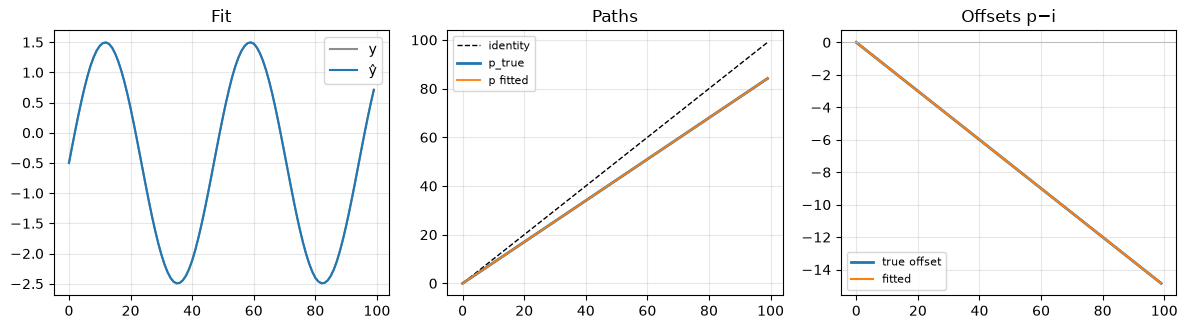

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].plot(idx, y, color="0.55", lw=1.5, label="y")
axes[0].plot(idx, fit["y_hat"], label="ŷ")
axes[0].set_title("Fit"); axes[0].legend()

axes[1].plot(idx, idx, "k--", lw=1, label="identity")
axes[1].plot(idx, p_true, label="p_true", lw=2)
axes[1].plot(idx, fit["p"], label="p fitted", alpha=0.9)
axes[1].set_title("Paths"); axes[1].legend(fontsize=8)

axes[2].plot(idx, p_true - idx, label="true offset", lw=2)
axes[2].plot(idx, fit["p"] - idx, label="fitted")
axes[2].axhline(0, color="0.7", lw=0.6)
axes[2].set_title("Offsets p−i"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()


## Takeaways

1. Soft-warp a covariate under a low-dimensional path (`WarpPath` + `WarpRegression`).
2. Attach any readout and train with ordinary optimizers.
3. Here the series is deterministic, so error-only is enough to recover the warp; dual loss and terror live in the next notebook.

Next: [`1_Introduction_to_Warp_Regression.ipynb`](1_Introduction_to_Warp_Regression.ipynb) — full model, dual loss, forecast bands, cycle-length uncertainty.
